In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

### Imports

In [2]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import numpy as np
import os
import re
import matplotlib.pyplot as plt

# DEV model's data

### Parameters

In [3]:
labels_compare = [
    'Development'
]

In [ ]:
args_compare = [
    { # DEVELOPMENT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    }
    # { # SMALLER INPUT
    #     'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
    #     'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
    #     'env' : 'box_messy',
    #     'env_dim': 0.635,
    #     'name_prefix': 'small_input',
    #     'pretrained_model_folder': False,
    #     'moredata': None,
    #     'n_gridcells': [0,0,0,0,25], # with GC
    #     'gridcells_softmax': [False,False,False,False,True], # with GC
    #     'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    #     'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    #     'n_future_pred' : 1,
    #     'frame_subsampling': 6,
    #     'stride' : 10,
    #     'reset_hidden_at': [None,None,None,None,10], # with GC
    #     'bptt_steps' : 9,
    #     'latent_dim' : 500,
    #     'bias': False,
    #     'dropouts': '[0,0,0]',
    #     'nonlinearity' : 'sigmoid',
    #     'hidden_reg' : 0.,
    #     'weights_reg' : 0.,
    #     'seed': 1,
    #     'epoch' : None,
    # }
    # { # REVERSE TRAINING
    #     'behaviour' : ['adult', 'run', 'walk', 'crawl', 'crawl'],
    #     'pretrained_behav' : ['adult', 'adult,run', 'adult,run,walk', 'adult,run,walk,crawl', 'crawl'],
    #     'env' : 'box_messy',
    #     'env_dim': 0.635,
    #     'name_prefix': None,
    #     'pretrained_model_folder': False,
    #     'moredata': None,
    #     'n_gridcells': [0,0,0,0,25], # with GC
    #     'gridcells_softmax': [False,False,False,False,True], # with GC
    #     'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
    #     'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
    #     'n_future_pred' : 1,
    #     'frame_subsampling': 4,
    #     'stride' : 10,
    #     'reset_hidden_at': [None,None,None,None,10], # with GC
    #     'bptt_steps' : 9,
    #     'latent_dim' : 500,
    #     'bias': False,
    #     'dropouts': '[0,0,0]',
    #     'nonlinearity' : 'sigmoid',
    #     'hidden_reg' : 0.,
    #     'weights_reg' : 0.,
    #     'seed': 1,
    #     'epoch' : None,
    # }
]

In [5]:
assert len(labels_compare) == len(args_compare)
for l, a in zip(labels_compare, args_compare):
    print(l, a['name_prefix'])

Development small_input


### Define Data

In [6]:
n_compare = [None]*len(args_compare)
for i, args in enumerate(args_compare):
    print("Comparison will be done on the following parameters:")
    for k, a in args.items():
        if isinstance(a, list):
            print(f"\t{k}: {a}")
            if n_compare[i] is None:
                n_compare[i] = len(a)
            elif n_compare[i] != len(a):
                raise ValueError("All lists must have the same length")
    print()

if None in n_compare:
    raise ValueError("At least one argument must be a list to make a comparison")

for i, args in enumerate(args_compare):
    for k, a in args.items():
        if not isinstance(a, list):
            args_compare[i][k] = [a] * n_compare[i]


Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]



In [7]:
from utils.trainer import RNNTrainer

activity_dirs_compare = []
models_compare = []

for a, args in enumerate(args_compare):
    print(labels_compare[a], "comparing the activity from the following directories:")
    ad = []
    m = []
    for i in range(n_compare[a]):
        model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args.items()})
        
        env_shape = args['env'][i].split('_')[0]
        trained_behav_list = args['pretrained_behav'][i].split(',')
        behav = trained_behav_list.pop()
        if len(trained_behav_list)>0:
            folder_name = '_'.join(trained_behav_list)
        else:
            folder_name = "vanilla"
        exp_dir = os.path.join(
            DATA_DIR, env_shape, behav, "predictions", args['env'][i],
            folder_name, model_name
        )

        activity_dir = f"act_{args['behaviour'][i]}_epoch"
        if args['epoch'][i] is not None:
            epoch = args['epoch'][i]
        else:
            dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
            epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

        m.append(
            torch.load(
                os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
                weights_only=False,
                map_location=torch.device(DEVICE)
            ).to(DEVICE)
        )
        ad.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

        print(ad[-1])
    activity_dirs_compare.append(ad)
    models_compare.append(m)
    print()

Development comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_small_input_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_small_input_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500



# Extract values

### Compare training

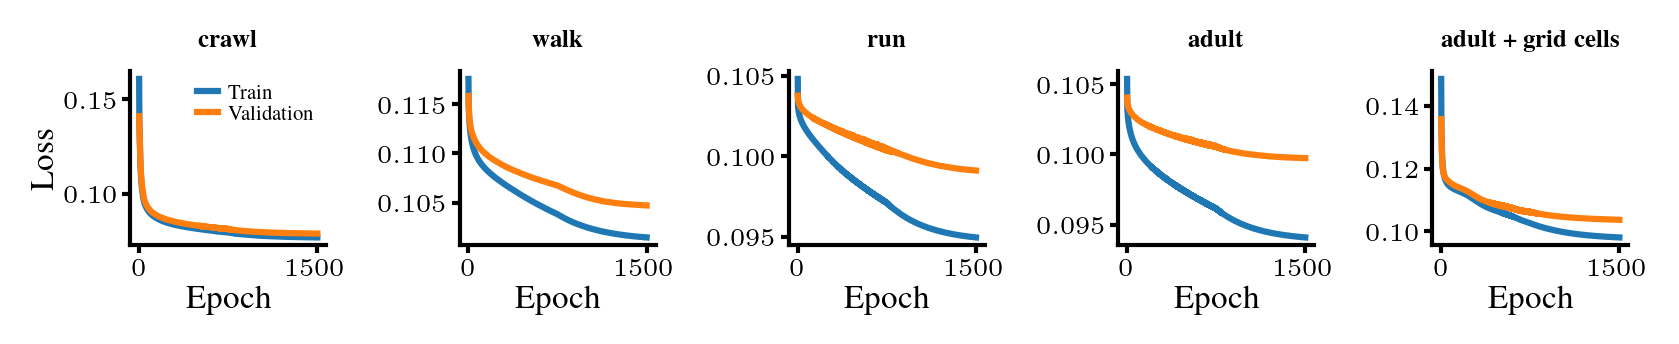

In [8]:
plt.style.use(os.path.join(BASE_DIR, 'matplotlib_style.mplstyle'))

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'
plt.rcParams['font.family'] = 'serif'

titles = [r'\textbf{crawl}', r'\textbf{walk}', r'\textbf{run}', r'\textbf{adult}', r'\textbf{adult + grid cells}']

for c, l in enumerate(labels_compare):
    os.makedirs(os.path.join(BASE_DIR, 'paper_figures', 'compare', l), exist_ok=True)

    fig, axs = plt.subplots(1, 5, figsize=(5.5, 1), dpi=300, layout="constrained")
    
    for idx, ad in enumerate(activity_dirs_compare[c]):
        loss_train = np.load(os.path.join('/'.join(ad.split('/')[:-1]), 'loss_train.npy'))
        loss_test = np.load(os.path.join('/'.join(ad.split('/')[:-1]), 'loss_test.npy'))
        ax = axs.flat[idx]

        ax.set_xlabel('Epoch')
        ax.set_xticks([0, 1500])

        ax.plot(loss_train, label='Train')
        ax.plot(loss_test, label='Validation')
        
        ax.set_title(titles[idx], fontsize=6)
        ax.spines[['right', 'top']].set_visible(False)

        if idx == 0:
            ax.set_ylabel('Loss')
            ax.legend(
                loc='upper right',
                frameon=False, borderpad=0.1, labelspacing=0.1,
                handletextpad=0.5, handlelength=1,
            )

    fig.get_layout_engine().set(h_pad=0.025, w_pad=0.05) #, hspace=0, wspace=0)

    # plt.savefig(
    #     os.path.join(BASE_DIR, 'paper_figures', 'suppfig_losses.pdf'),
    #     dpi=300, bbox_inches='tight', pad_inches=0.04
    # )
    plt.show()

# END